# Qubit coupled to Two-level system (TLS) with white noise

### Author: Daniel Gonçalves Benvenutti - UNICAMP
15 August 2025

Qutip Version: 5.2.0









In [1]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 15.5 MB/s eta 0:00:00


In [1]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lsim, TransferFunction
from tqdm import tqdm
from scipy.signal import welch

## Simulation Parameters



In [ ]:

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

sm0=qtp.tensor(sm, qtp.qeye(2))
sx0=qtp.tensor(sx, qtp.qeye(2))
sz0=qtp.tensor(sz, qtp.qeye(2))
sy0=qtp.tensor(sy, qtp.qeye(2))
n0=qtp.tensor(n, qtp.qeye(2))

sm1=qtp.tensor(qtp.qeye(2), sm)
sx1=qtp.tensor(qtp.qeye(2), sx)
sz1=qtp.tensor(qtp.qeye(2), sz)
n1=qtp.tensor(qtp.qeye(2), n)


# hamiltonian
def H(wq0,wq1, g, norm,  Ed1_t, Ed0_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  H0 = -0.5*wq0*sz0
  H1 = -0.5*wq1*sz1
  Hint = g*(sm1.dag()*sm0+sm1*sm0.dag())
  H = (H0 + H1 + Hint)/norm

# Use basic hamiltonian if there's no drive
  if Ed1_t is None and Ed0_t is None:
    return H

  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  #There is noise in TLS 1
  Ham = [H] #list with the time independant hamiltonians
  if Ed1_t is not None:
    Ham.append([sx1/norm,Ed1_t])
    #There's noise in Qubit 0
  if Ed0_t is not None:
    Ham.append([sx0/norm,Ed0_t])
  return qtp.QobjEvo(Ham,tlist=tlist*norm)

# colapse operators normalized by wq
def c_ops(T1_0,T2_0, T1_1,T2_1, norm): #T1[ns], T2[ns]
  if T2_0 is None or T2_1 is None:
    return [np.sqrt(1/T1_0/norm)*sm0, np.sqrt(1/T1_1/norm)*sm1]

  # (T2 must be T2<=2T1)
  elif T2_0>2*T1_0:
    raise Exception("Qubit T2 must be T2<=2T1")
  elif T2_1>2*T1_1:
    raise Exception("TLS T2 must be T2<=2T1")

  gamma_phi_0=1/T2_0-1/2/T1_0 #pure dephasing constant
  gamma_phi_1=1/T2_1-1/2/T1_1 #pure dephasing constant
  return [np.sqrt(1/T1_0/norm)*sm0,np.sqrt(gamma_phi_0/2/norm)*sz0, np.sqrt(1/T1_1/norm)*sm1,np.sqrt(gamma_phi_1/2/norm)*sz1, ]

def noise_psd(tlist, psd = lambda f: 1):
    N=len(tlist)
    X_white = np.fft.rfft(np.random.randn(N))
    S = psd( np.fft.rfftfreq(N, d=tlist[1]-tlist[0]) )
    # Normalize S
    S = S / np.sqrt(np.mean(S**2))
    X_shaped = X_white * S
    return np.fft.irfft(X_shaped, n=N)

def PSDGenerator(f):
    return lambda N: noise_psd(N, f)

@PSDGenerator
def brownian_noise(f):
    return 1/np.where(f == 0, float('inf'), f)

@PSDGenerator
def pink_noise(f):
    return 1/np.where(f == 0, float('inf'), np.sqrt(f))

def band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    # n stages

    #Y(s)=H(s)X(s)
    wc=2*np.pi*fc
    w0=2*np.pi*f0

    #multiples numerator and denominator polynomials of the filter transfer function n times
    num,den=[1],[1]
    for _ in range( n):
        num = np.polymul(num, [1, 0, w0**2])
        den = np.polymul(den, [1, wc, w0**2])
    #system H(s)^n
    tf=TransferFunction(num,den)

    #y(t)
    _, y_t, _ = lsim(tf, U=x_t, T=tlist)
    return y_t

def simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=None, Ed1=None, e="xyz",psi0=qtp.tensor(qtp.basis(2,0), qtp.basis(2,0))):
  # Normalization factor for simulation
  # use bigger between resonances
  norm=max(wq1, wq0, np.sqrt((wq1-wq0)**2+4*g**2)/2+wq1/2+wq0/2)
  #print(f"norm: ",norm/np.pi/2, "GHz")
  #pi_pulse=np.pi/Ed #[ns]
  #print(f"pi pulse={pi_pulse:.2f} ns")

  lenght=100_000 #ns
  #White noise generator
  tlist=np.linspace(0,lenght,int(lenght*6*norm/2/np.pi))
  if Ed0 is None:
     drive_data0= None
  else:
    drive_data0=Ed0(tlist)
  if Ed1 is None:
     drive_data1= None
  else:
    drive_data1=Ed1(tlist)

# Expected value operators in qubit 0
  e_ops=[]
  if "x" in e:
    e_ops.append(sx0)
  if "y" in e:
    e_ops.append(sy0)
  if "z" in e:
    e_ops.append(sz0)
  #simulation steps
  t=np.linspace(0,lenght,int(lenght*2.2*norm/2/np.pi)) #ns

  # simulation
  H_total=H(wq0,wq1, g, norm,drive_data1, drive_data0,tlist)
  col=c_ops(T1_0,T2_0, T1_1,T2_1,norm)

  res=qtp.mesolve(H_total,psi0,t*norm,c_ops=col,e_ops=e_ops,options=dict(nsteps=None, progress_bar=""))
  return t, res

# Plots

In [166]:
def plot_fft_tomography(t, expect, graphs="xyz", nperseg=256):
  # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))  # Adjust figure size as needed
  axes = np.atleast_1d(axes)

  # Calculate the corresponding frequencies
  dt=t[1] - t[0]

  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(*welch(expect[graphs.index("x")], fs=1/dt, nperseg=nperseg))
    axes[graphs.index("x")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title('Tomography of the noisy oscillation \n Expectation Value of $\\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(*welch(expect[graphs.index("y")],fs=1/dt, nperseg=nperseg))
    axes[graphs.index("y")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title('Expectation Value of $\\sigma_y$')

  # Plot sz
  if "z" in graphs:
    w=welch(expect[graphs.index("z")],fs=1/dt, nperseg=nperseg)
    DC=w[1][0]
    w = [v[1:] for v in w]
    axes[graphs.index("z")].plot(*w)
    axes[graphs.index("z")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title('Expectation Value of $\\sigma_z$')
    print(f"DC: {DC}")


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def plot_tomography(t, expect, graphs="xyz"):
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))   # Adjust figure size as needed
  axes = np.atleast_1d(axes)
  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(t, expect[graphs.index("x")])
    axes[graphs.index("x")].set_xlabel('Time (ns)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title('Tomography of the noisy oscillation \n Expectation Value of $\\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(t, expect[graphs.index("y")])
    axes[graphs.index("y")].set_xlabel('Time (ns)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title('Expectation Value of $\\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(t, expect[graphs.index("z")])
    axes[graphs.index("z")].set_xlabel('Time (ns)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title('Expectation Value of $\\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def diffusive_scale(dt, signal):
    """
    Returns the slope of variance vs lag in log-log scale
    For pure Brownian motion, slope ≈ 1
    """
    n = len(signal)
    lags = np.arange(1, n//2)
    variances = [np.var(signal[lag:] - signal[:-lag]) for lag in lags]
    slope, _ = np.polyfit(np.log(dt*lags), np.log(variances), 1)
    #diffusive scale
    D=slope
    return D

def lorenztian_fit(t, sigz, T, split =100, nperseg=256):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  #freq = np.fft.rfftfreq(len(t), d=dt)

  start=1 # remove DC
  split=split
  # FFT of sigz betweeen start and split
  #X=np.abs(np.fft.rfft(sigz))[start:split]
  #freq_subset = freq[start:split]
  
  freq,X =welch(sigz, fs=1/dt, nperseg=nperseg)
  freq_subset=freq[start:split]
  X=X[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset):
    return A / (1 + (f/gamma)**2)+offset
  plt.plot(freq_subset, X, label='Original Data')
  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(r'Expectation Value of $\sigma_z$ with Lorentzian Fit')
  # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[np.max(X)-np.min(X),1/T, np.min(X)])

  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit)

  # Plot the original data and the fitted curve
  
  plt.plot(freq_subset, X_fit, label='Fit', color='red')

  plt.legend()
  plt.show()

  print(f"Fitted gamma: {gamma_fit:.2e}")
  print(f"Fitted 1/gamma: {1/gamma_fit:.2e}")
  print(f"Fitted gamma*2pi: {gamma_fit*2*np.pi:.2e}")
  print(f"Fitted 1/gamma/2pi: {1/gamma_fit/2/np.pi:.2e}")
  print(f"Fitted Offset: {offset_fit:.2e}")
  print(f"Fitted Amplitude : {A_fit:.2e}")
  print(f"var of increments (volatility): {np.var([j-i for i, j in zip(sigz[:-1], sigz[1:])])}")


def peak_zoom(t, sigz, T, peak,zoom=0.5, opt="z",nperseg=256):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  
  freq,X =welch(sigz, fs=1/dt, nperseg=nperseg)
  start=np.where(freq>=peak-zoom)[0][0]
  split=np.where(freq<=peak+zoom)[0][-1]
  freq_subset=freq[start:split]
  X=X[start:split]
  print(len(X))
  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset,f0):
    return A / (1 + ((f-f0)/gamma)**2) + offset
  # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')
  #try:
    # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[np.max(X)-np.min(X),1/T, np.min(X), freq_subset[np.argmax(X)] ])
  #except:
  #  pass
  #else:
  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit, f0_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit, f0_fit)
  plt.plot(freq_subset, X_fit, label=fr'Fit', color='red')
  print(f"Fitted gamma: {gamma_fit:.2e}")
  print(f"Fitted 1/gamma: {1/gamma_fit:.2e}")
  print(f"Fitted gamma*2pi: {gamma_fit*2*np.pi:.2e}")
  print(f"Fitted 1/gamma/2pi: {1/gamma_fit/2/np.pi:.2e}")
  print(f"Fitted Offset: {offset_fit:.2e}")
  print(f"Fitted f0: {f0_fit:.2e}")
  print(f"Fitted Amplitude : {A_fit:.2e}")

  plt.xlabel('Frequency (GHz)')
  plt.ylabel(f'<σ{opt}>')
  plt.title(f'Expectation Value of $\\sigma_{opt}$ with Lorentzian Fit')
  plt.legend()
  plt.show()


# Simulations

$f_{z peak}=\sqrt{\Delta^2+4g^2}$

$f_{x peaks}=\frac{f_0+f_1}{2} \pm \frac{\sqrt{\Delta^2+4g^2}}{2}$



## g difference
### g=1

### g=1.5

In [213]:
# parameters

g=1.5*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=300 #dephasing time [ns]
amp0=0.008*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]



peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0)
print("minres: ", 1/(t[1]-t[0])/len(t))

3.605551275463989
minres:  9.999992166754139e-06


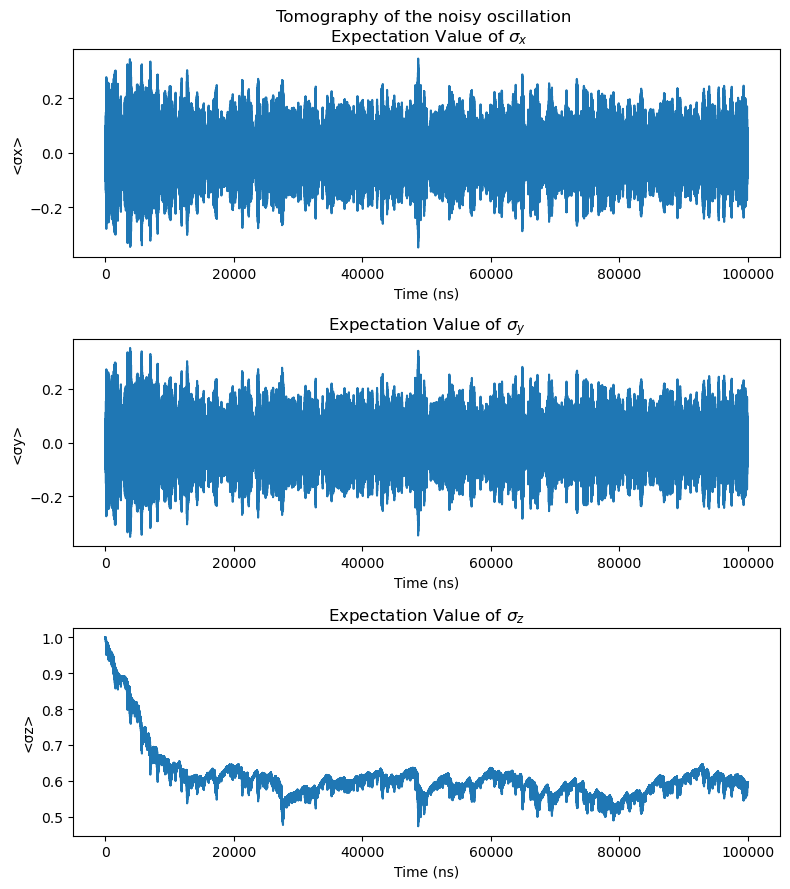

In [214]:
plot_tomography(t, res.expect)

DC: 0.00031795154508856783


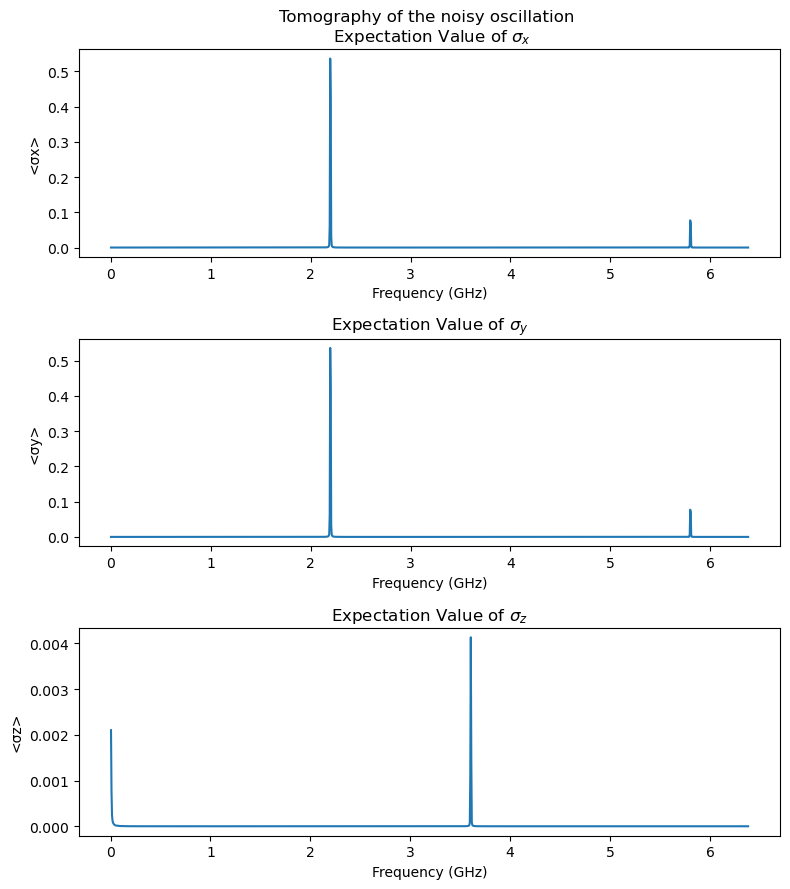

In [215]:
resolution=0.005
plot_fft_tomography(t, res.expect, nperseg=int(1/(t[1]-t[0])/resolution) )

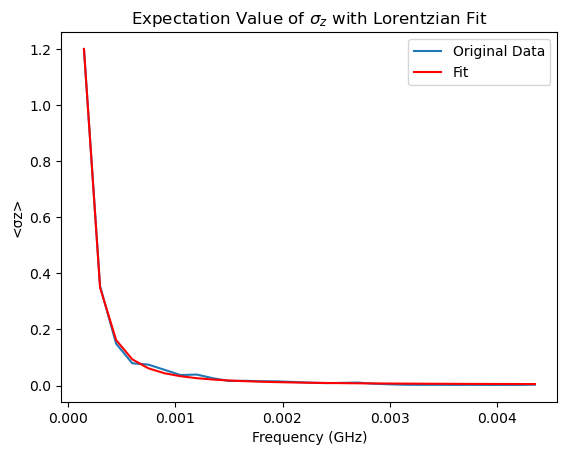

Fitted gamma: 7.04e-05
Fitted 1/gamma: 1.42e+04
Fitted gamma*2pi: 4.42e-04
Fitted 1/gamma/2pi: 2.26e+03
Fitted Offset: 3.51e-03
Fitted Amplitude : 6.63e+00
var of increments (volatility): 8.505474612754391e-05


In [ ]:
resolution=0.00015
lorenztian_fit(t, res.expect[2], 2000, split=30 ,nperseg=int(1/(t[1]-t[0])/resolution))

999
Fitted gamma: 4.80e-04
Fitted 1/gamma: 2.08e+03
Fitted gamma*2pi: 3.01e-03
Fitted 1/gamma/2pi: 3.32e+02
Fitted Offset: 7.37e-06
Fitted f0: 3.61e+00
Fitted Amplitude : 2.17e-02


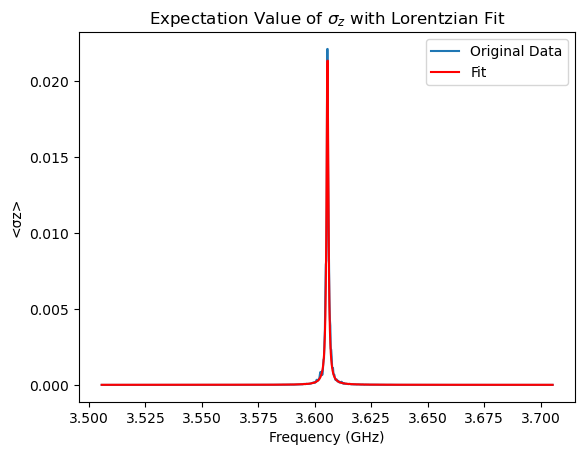

In [232]:
resolution=0.0002
peak_zoom(t, res.expect[2], T2_1, peak,zoom=0.1,nperseg=int(1/(t[1]-t[0])/resolution))

### g=1

In [129]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=500 #dephasing time [ns]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.008*2*np.pi #driving energy [GHz.rad]

def Ed1(tlist):
    return amp1*np.random.normal(0,1,len(tlist))


peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1=Ed1)

2.8284271247461903


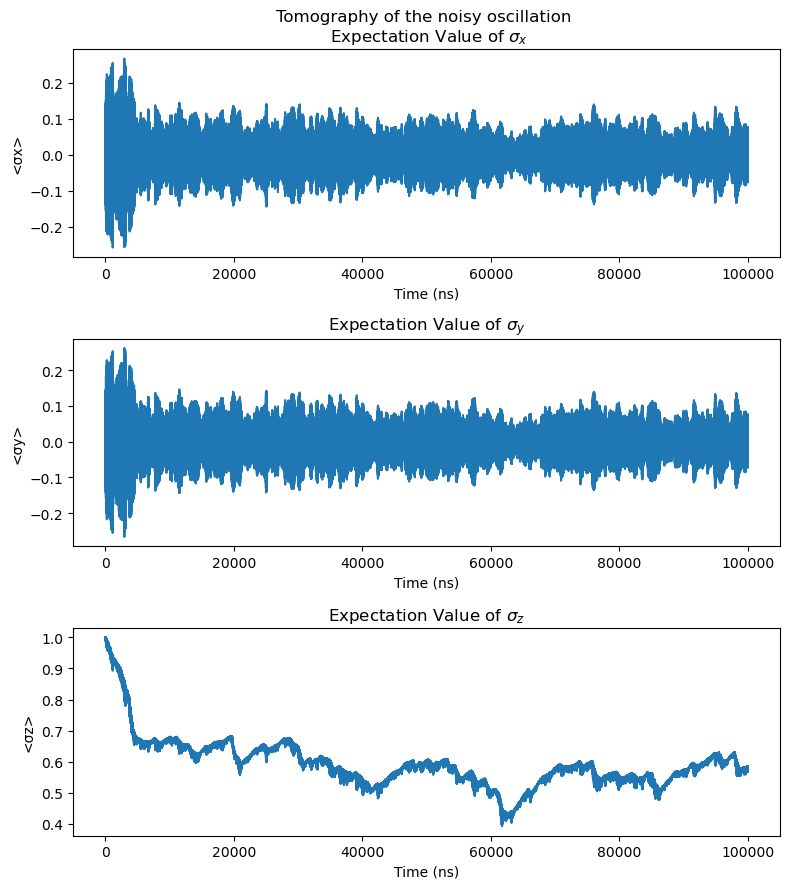

In [132]:
plot_tomography(t, res.expect)

DC: 0.0031262421576180696


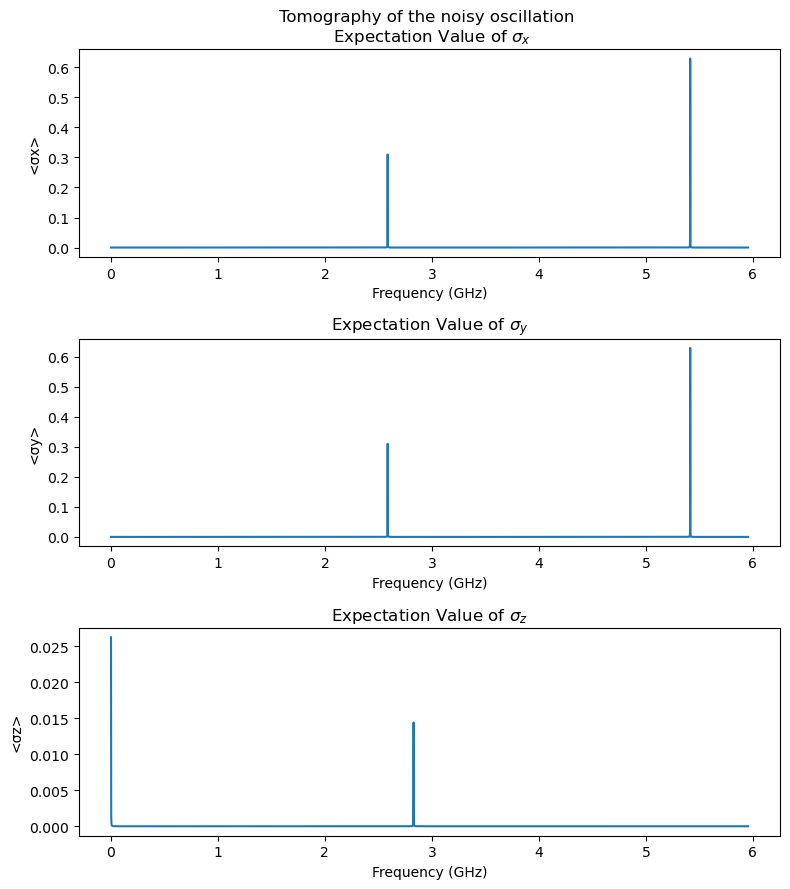

In [151]:
plot_fft_tomography(t, res.expect, nperseg=int(t[-1]/2000*256) )

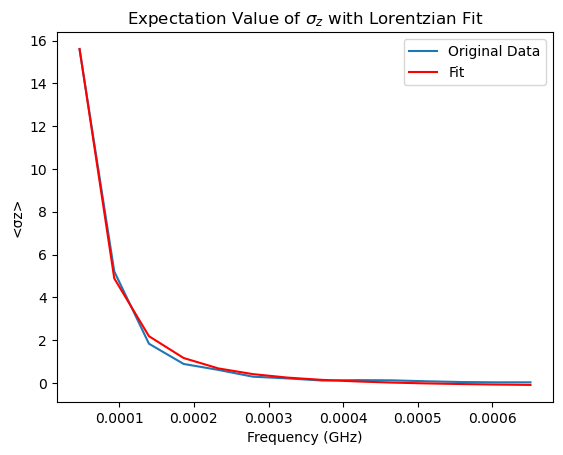

Fitted gamma: -3.04e-05
Fitted 1/gamma: -3.29e+04
Fitted gamma*2pi: -1.91e-04
Fitted 1/gamma/2pi: -5.24e+03
Fitted Offset: -2.06e-01
Fitted Amplitude : 5.30e+01
var of increments (volatility): 7.006113442344497e-05


In [175]:
lorenztian_fit(t, res.expect[2], 5000, split=15,nperseg=int(t[-1]/100*256))

214
Fitted gamma: 3.07e-04
Fitted 1/gamma: 3.26e+03
Fitted gamma*2pi: 1.93e-03
Fitted 1/gamma/2pi: 5.18e+02
Fitted Offset: 7.88e-05
Fitted f0: 2.83e+00
Fitted Amplitude : 3.67e-02


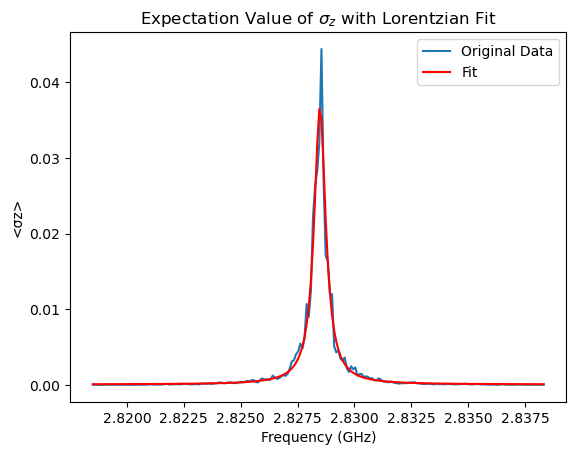

In [173]:
peak_zoom(t, res.expect[2], T2_1, peak,zoom=0.01,nperseg=int(t[-1]/200*256))

### g=0.5

In [194]:
# parameters

g=0.5*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=300 #dephasing time [ns]
amp0=0.008*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]



peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0)
print("minres: ", 1/(t[1]-t[0])/len(t))

2.23606797749979
minres:  9.999991118745044e-06


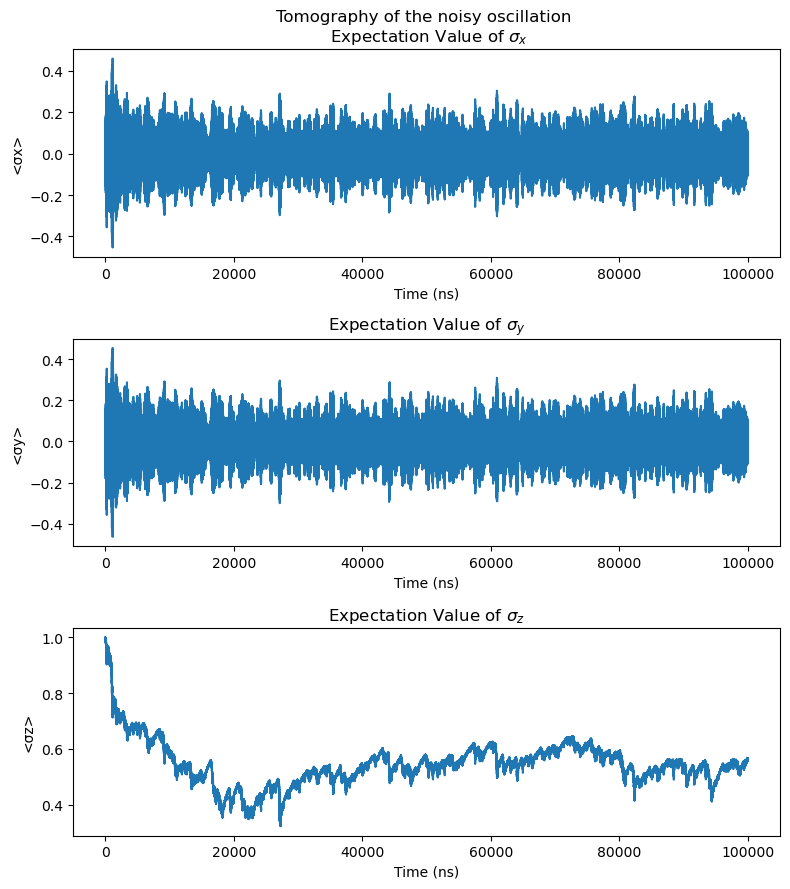

In [195]:
plot_tomography(t, res.expect)

DC: 0.0006179274753878451


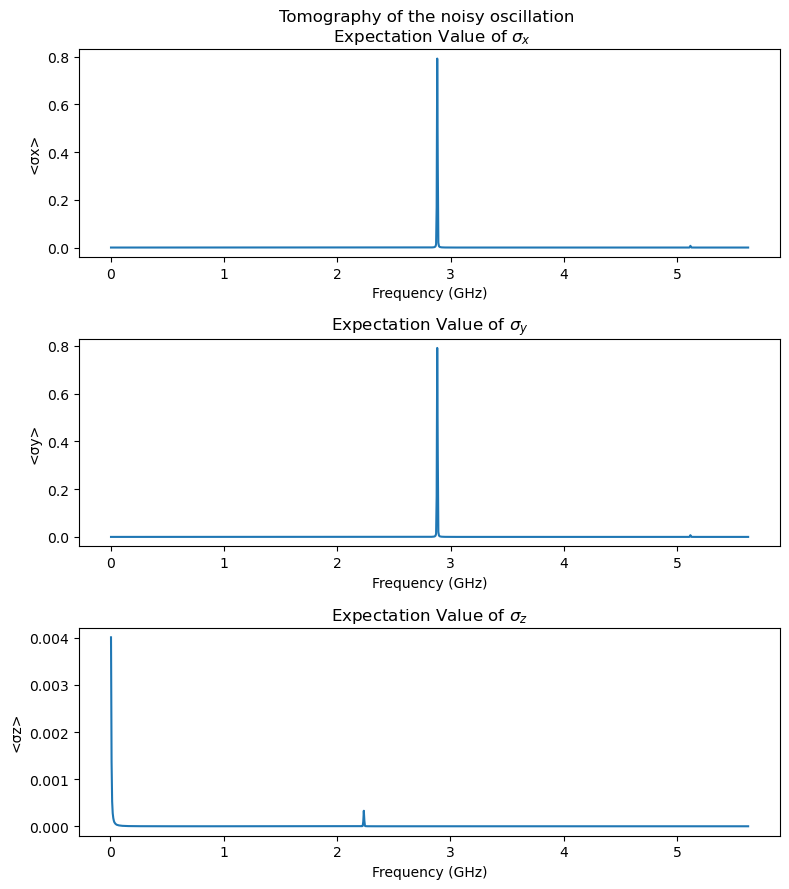

In [212]:
resolution=0.005
plot_fft_tomography(t, res.expect, nperseg=int(1/(t[1]-t[0])/resolution) )

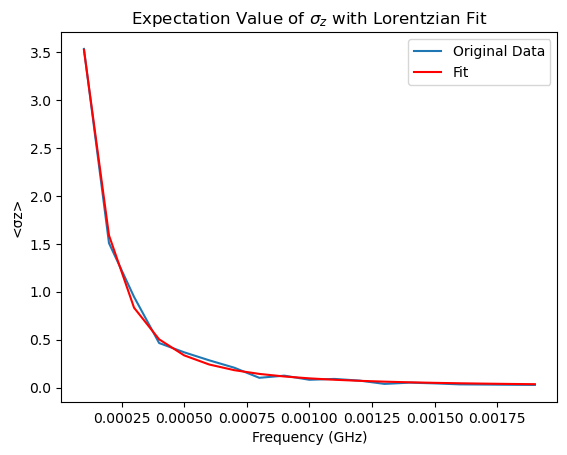

Fitted gamma: 1.20e-04
Fitted 1/gamma: 8.32e+03
Fitted gamma*2pi: 7.55e-04
Fitted 1/gamma/2pi: 1.32e+03
Fitted Offset: 1.21e-02
Fitted Amplitude : 5.94e+00
var of increments (volatility): 4.135893196266147e-06


In [206]:
resolution=0.0001
lorenztian_fit(t, res.expect[2], 2000, split=20,nperseg=int(1/(t[1]-t[0])/resolution))

999
Fitted gamma: 7.23e-04
Fitted 1/gamma: 1.38e+03
Fitted gamma*2pi: 4.54e-03
Fitted 1/gamma/2pi: 2.20e+02
Fitted Offset: -2.25e-07
Fitted f0: 2.24e+00
Fitted Amplitude : 1.27e-03


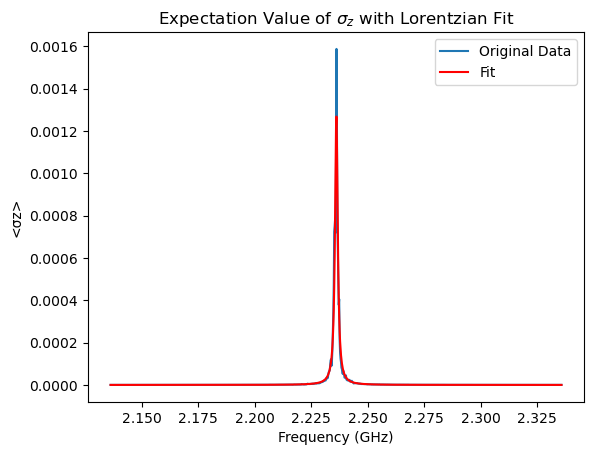

In [207]:
resolution=0.0002
peak_zoom(t, res.expect[2], T2_1, peak,zoom=0.1,nperseg=int(1/(t[1]-t[0])/resolution))

## Split noise source peak with drive
### Qubit 0 noise

In [106]:
# parameters
samples = 5
g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.128*2*np.pi #driving energy [GHz.rad]
amp0drive=0.1*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))+amp0drive*np.sin((wq1+wq0+2*np.pi*peak)/2*tlist)


exp=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0)
    if len(exp)==0:
        exp = np.array(res.expect)/samples
    else:    
        exp += np.array(res.expect)/samples

2.8284271247461903


100%|██████████| 5/5 [12:55<00:00, 155.11s/it]


DC: (12583.963221752389+0j)


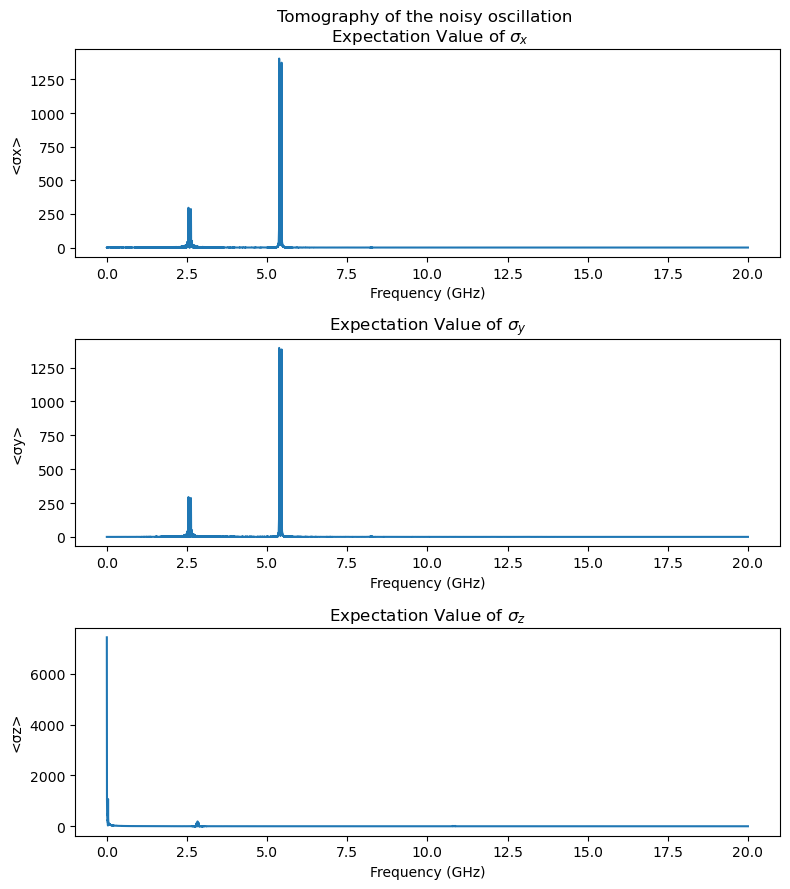

In [107]:
plot_fft_tomography(t, exp)

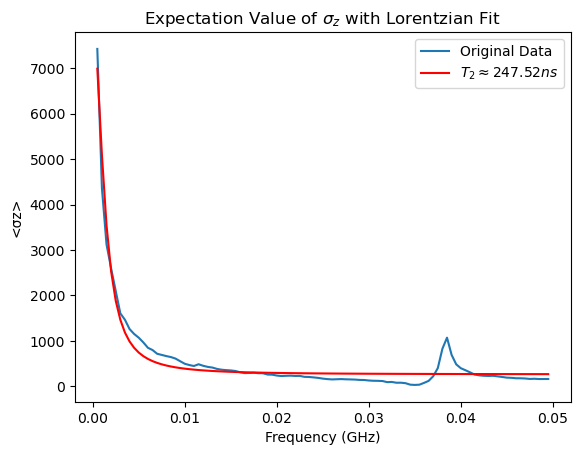

Fitted Offset: 263.10
Fitted Amplitude (S0): 7746.17
Fitted T2 247.52 ns
std of increments (volatility): 2.808830860916901e-05


In [108]:
lorenztian_fit(t, exp[2], T2_0)

Fitted Offset: 14.71
Fitted Amplitude (S0): 128.73
Fitted T2 127.71 ns
Fitted f0 2.83 GHz


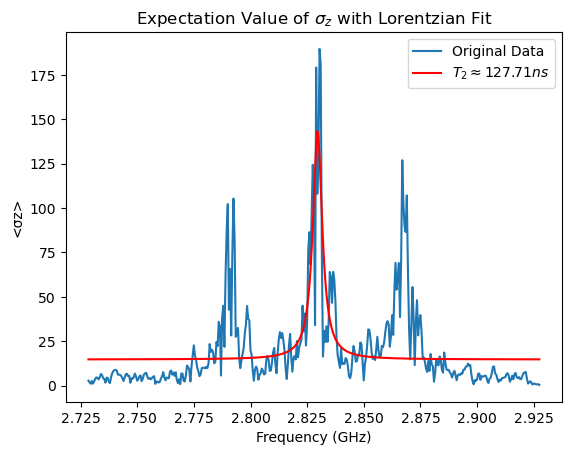

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

Fitted Offset: 36.43
Fitted Amplitude (S0): -37.89
Fitted T2 -36.77 ns
Fitted f0 2.58 GHz


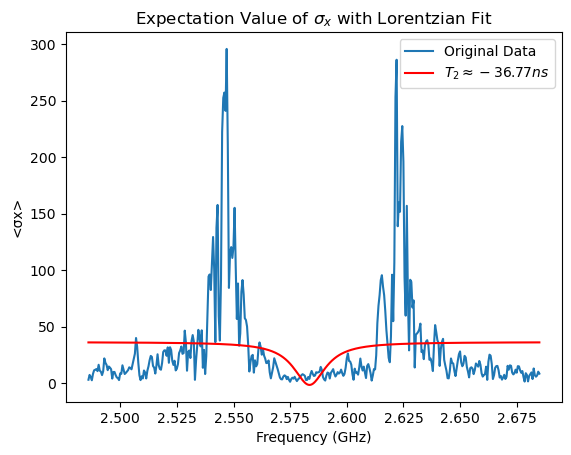

In [ ]:
peak_zoom(t, exp[0], T2_1, peak=-peak/2+3/2+5/2,zoom=0.1, opt="x")

Fitted Offset: 68.50
Fitted Amplitude (S0): 284.94
Fitted T2 430.48 ns
Fitted f0 5.41 GHz


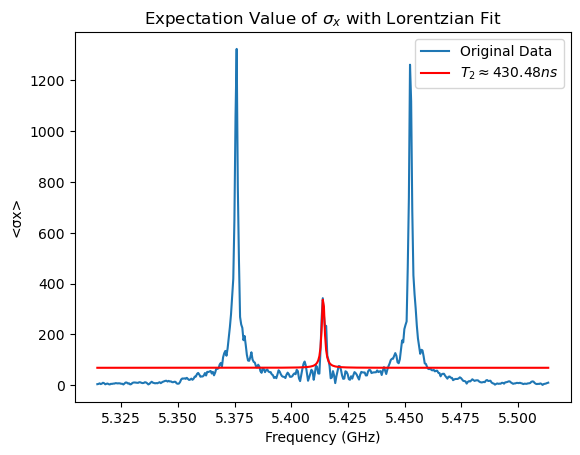

In [ ]:
peak_zoom(t, res.expect[0], T2_1, peak=+peak/2+3/2+5/2,zoom=0.1, opt="x")

### TLS 1 noise

In [100]:
# parameters
samples = 5
g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0drive=0.1*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0drive*np.sin((wq1+wq0+2*np.pi*peak)/2*tlist)
#Ed0=None
def Ed1(tlist):
    return amp1*np.random.normal(0,1,len(tlist))
print(peak)
exp=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0, Ed1=Ed1)
    if len(exp)==0:
        exp = np.array(res.expect)/samples
    else:    
        exp += np.array(res.expect)/samples

2.8284271247461903


100%|██████████| 5/5 [17:24<00:00, 208.93s/it]


DC: (18259.970184819285+0j)


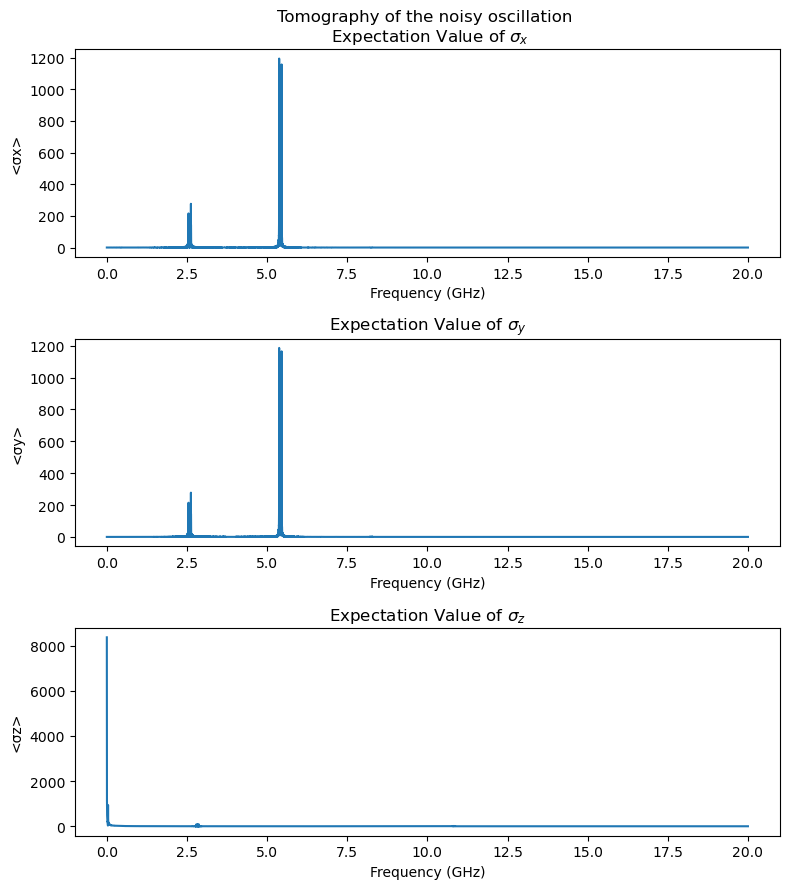

In [101]:
plot_fft_tomography(t, exp)

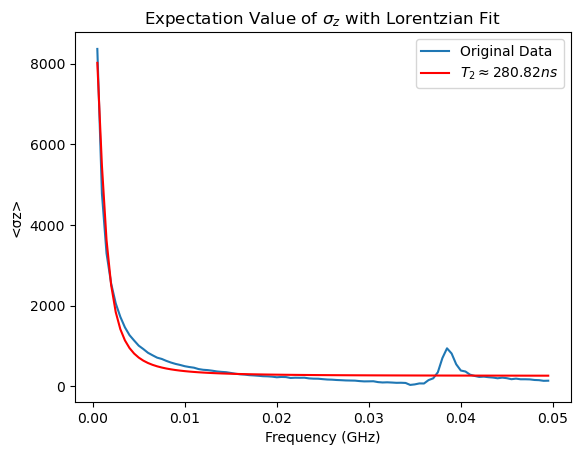

Fitted Offset: 256.93
Fitted Amplitude (S0): 9273.57
Fitted T2 280.82 ns
std of increments (volatility): 9.686379872731388e-06


In [102]:
lorenztian_fit(t, exp[2], T2_1,split=200)

Fitted Offset: 8.59
Fitted Amplitude (S0): 59.04
Fitted T2 138.94 ns
Fitted f0 2.83 GHz


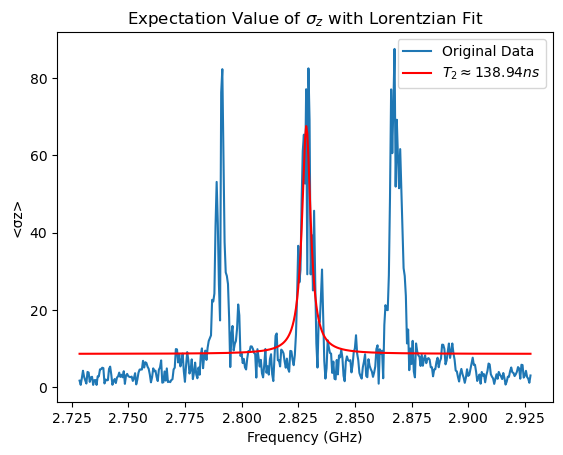

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

Fitted Offset: 19.23
Fitted Amplitude (S0): 50.87
Fitted T2 44314101.27 ns
Fitted f0 2.59 GHz


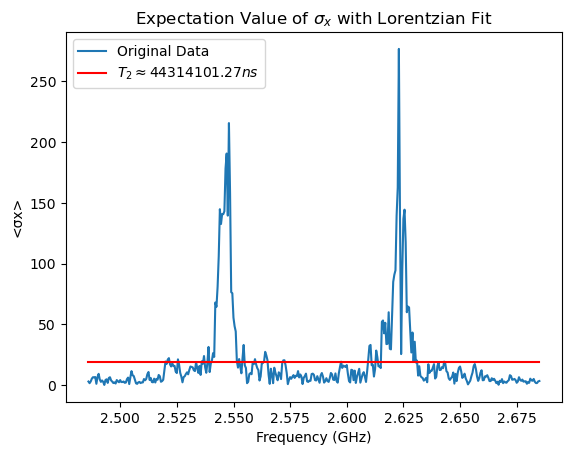

In [ ]:
peak_zoom(t, exp[0], T2_1, peak=-peak/2+3/2+5/2,zoom=0.1, opt="x")

Fitted Offset: 68.28
Fitted Amplitude (S0): 16122.70
Fitted T2 5112.80 ns
Fitted f0 5.41 GHz


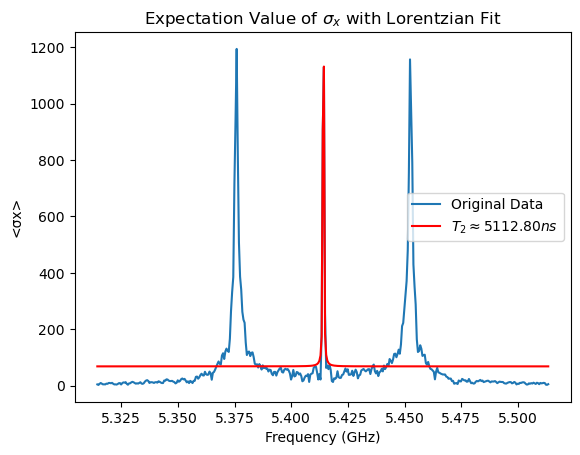

In [ ]:
peak_zoom(t, exp[0], T2_1, peak=+peak/2+3/2+5/2,zoom=0.1, opt="x")

## Detuning baseline subtraction

### Far detuned no Ed1

In [ ]:
# parameters
samples = 1
g=0.5*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=2*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.01*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=7*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))
#Ed0=None

print(peak)
exp=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0,)
    if len(exp)==0:
        exp = np.array(res.expect)
    else:    
        exp += np.array(res.expect)

5.0990195135927845


100%|██████████| 1/1 [06:55<00:00, 415.41s/it]


/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


DC: (111372.4556292074+0j)


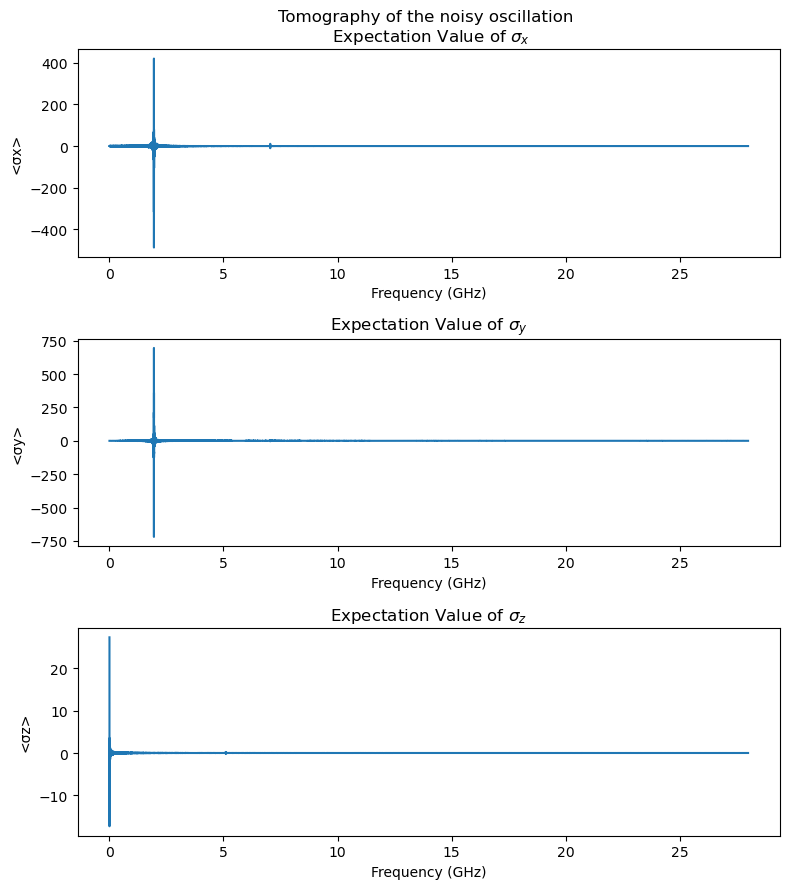

In [84]:
plot_fft_tomography(t, exp)

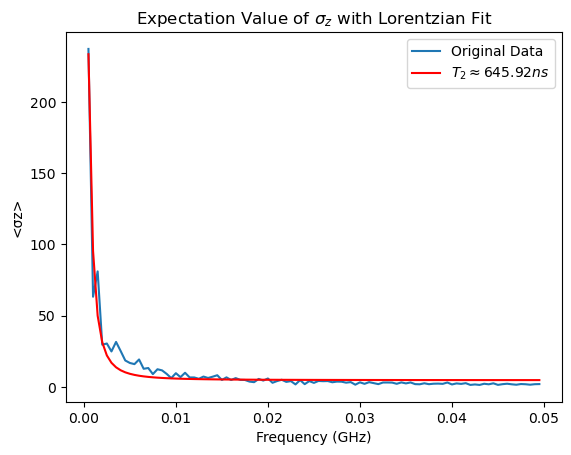

Fitted Offset: 4.71
Fitted Amplitude (S0): 464.49
Fitted T2 645.92 ns
std of increments (volatility): 1.1381126555637164e-10


In [85]:
lorenztian_fit(t, exp[2], T2_1,split=200)

Fitted Offset: 0.02
Fitted Amplitude (S0): 0.18
Fitted T2 124.95 ns
Fitted f0 5.10 GHz


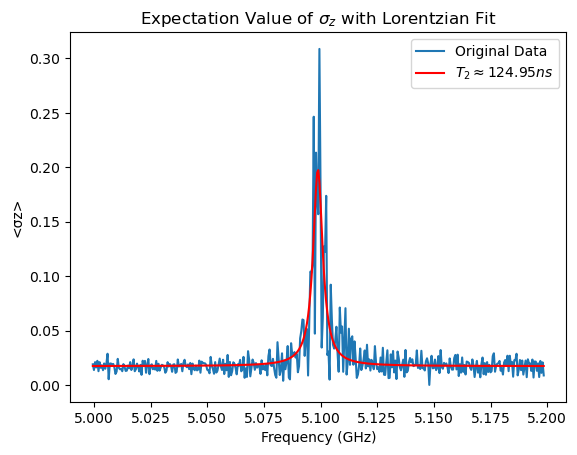

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

### Far Detuned with Ed1

In [112]:
# parameters
samples = 1
g=0.5*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=2*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.01*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=7*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))
#Ed0=None
def Ed1(tlist):
    return amp1*np.random.normal(0,1,len(tlist))
print(peak)
exp=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0, Ed1=Ed1)
    if len(exp)==0:
        exp = np.array(res.expect)
    else:    
        exp += np.array(res.expect)

5.0990195135927845


100%|██████████| 1/1 [06:12<00:00, 372.45s/it]


DC: (105904.5397577209+0j)


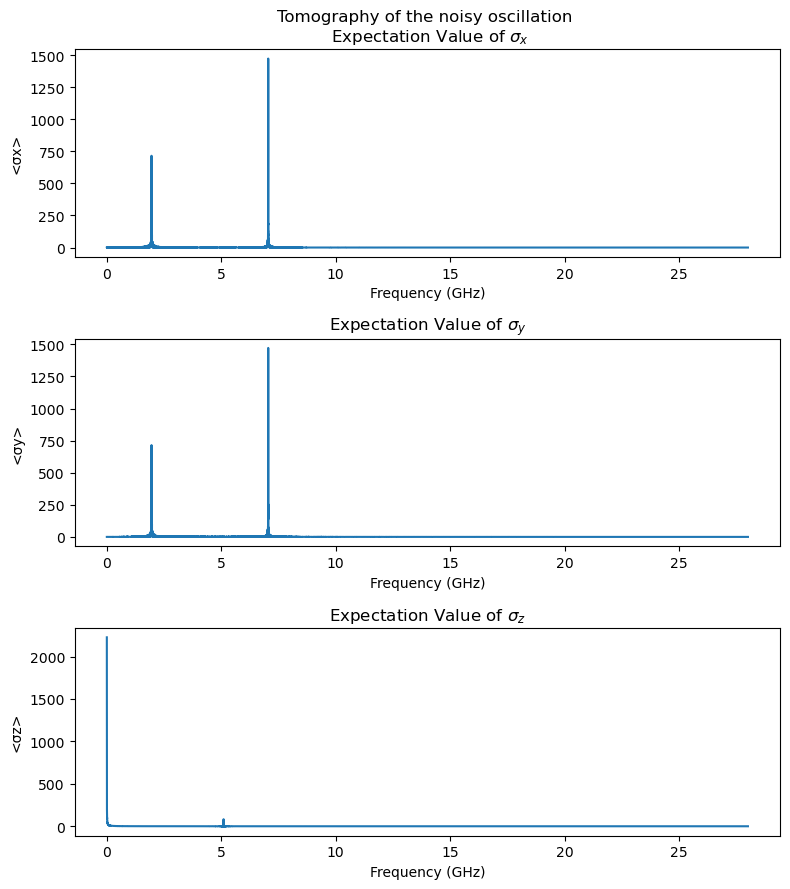

In [113]:
plot_fft_tomography(t, exp)

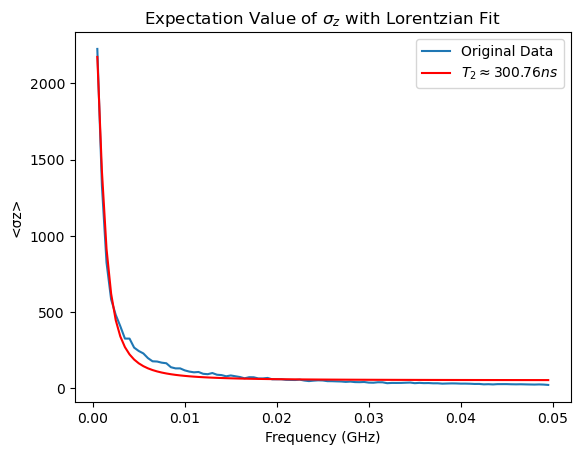

Fitted Offset: 52.37
Fitted Amplitude (S0): 2595.12
Fitted T2 300.76 ns
std of increments (volatility): 1.2624668313912352e-06


In [114]:
lorenztian_fit(t, exp[2], T2_1,split=200)

Fitted Offset: 1.08
Fitted Amplitude (S0): 46.84
Fitted T2 128.22 ns
Fitted f0 5.10 GHz


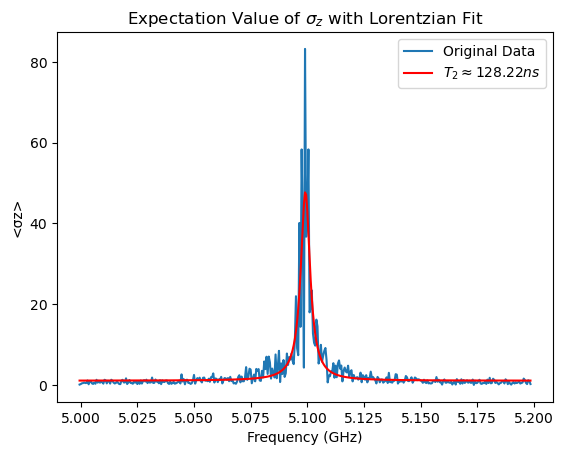

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

### Resonance no Ed1

In [116]:
# parameters
samples = 1
g=0.5*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=7*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.01*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=7*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))

print(peak)
exp=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0)
    if len(exp)==0:
        exp = np.array(res.expect)
    else:    
        exp += np.array(res.expect)

1.0


100%|██████████| 1/1 [02:02<00:00, 122.12s/it]


DC: (111657.54993585823+0j)


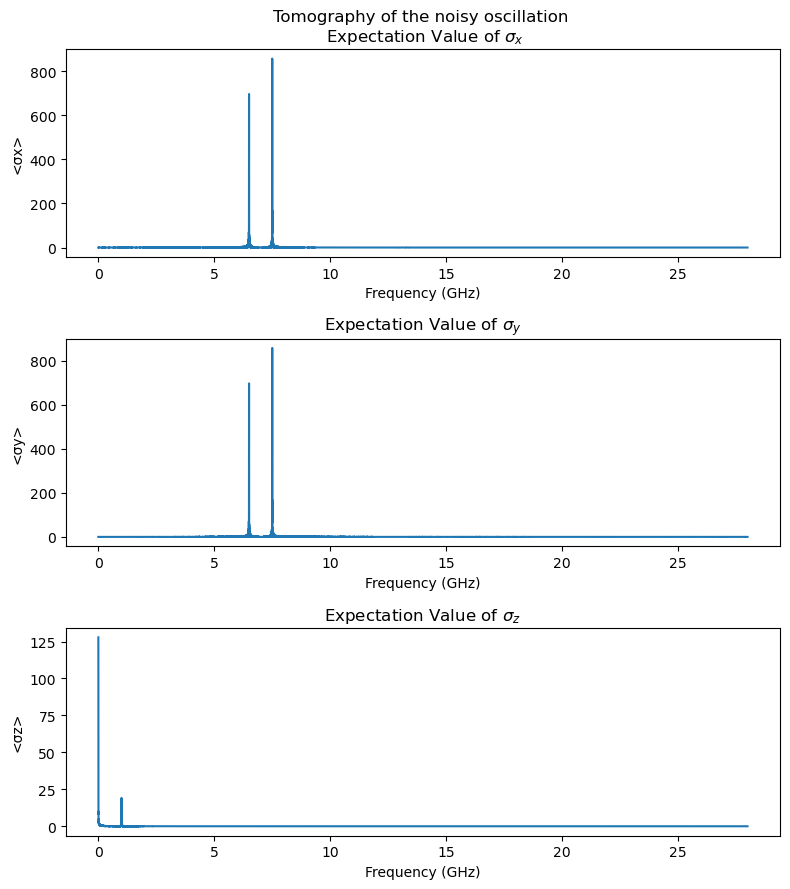

In [117]:
plot_fft_tomography(t, exp)

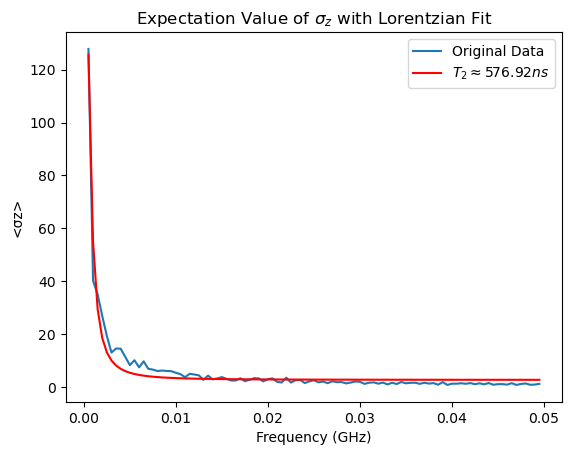

Fitted Offset: 2.64
Fitted Amplitude (S0): 224.09
Fitted T2 576.92 ns
std of increments (volatility): 1.6139212742595527e-09


In [118]:
lorenztian_fit(t, exp[2], T2_1,split=200)

Fitted Offset: 0.29
Fitted Amplitude (S0): 19.87
Fitted T2 659.55 ns
Fitted f0 1.00 GHz


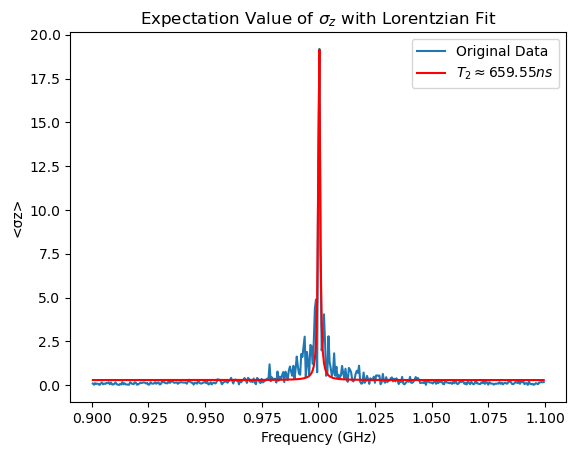

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

### Resonance with Ed1 

In [120]:
# parameters
samples = 1
g=0.5*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=7*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.01*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=7*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))
#Ed0=None
def Ed1(tlist):
    return amp1*np.random.normal(0,1,len(tlist))
print(peak)
exp=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0, Ed1=Ed1)
    if len(exp)==0:
        exp = np.array(res.expect)
    else:    
        exp += np.array(res.expect)

1.0


100%|██████████| 1/1 [02:38<00:00, 158.71s/it]


DC: (77763.43344459895+0j)


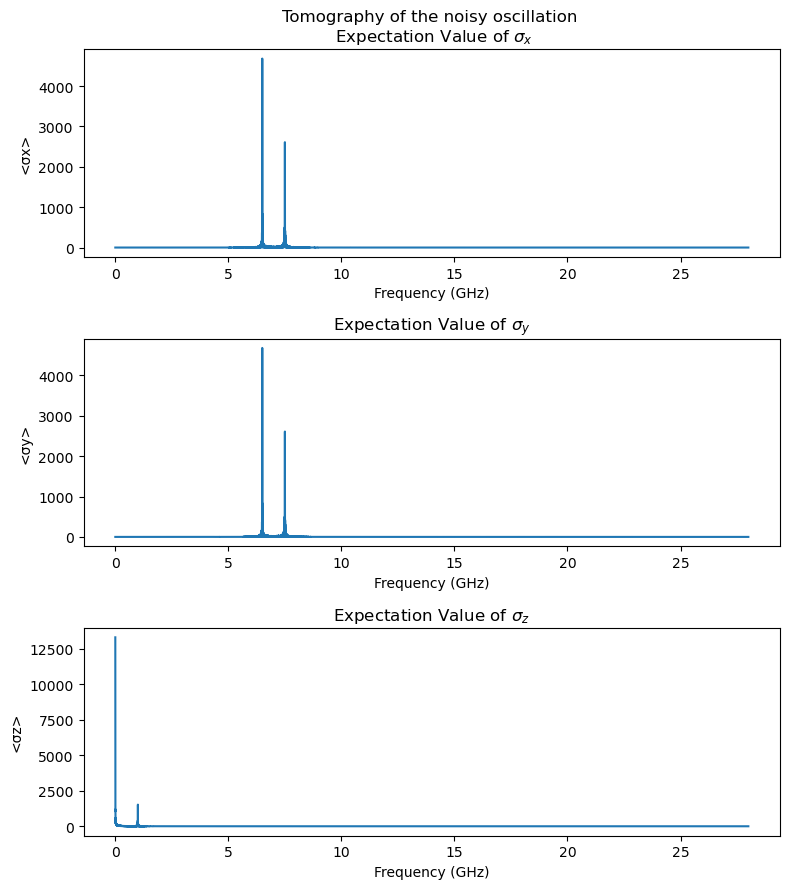

In [121]:
plot_fft_tomography(t, exp)

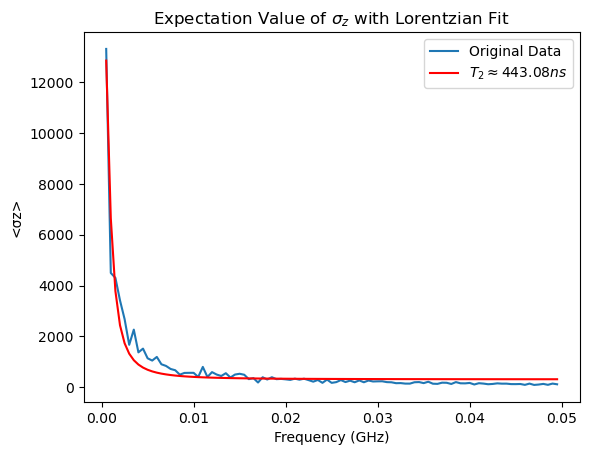

Fitted Offset: 314.41
Fitted Amplitude (S0): 18609.27
Fitted T2 443.08 ns
std of increments (volatility): 1.759425297155447e-05


In [122]:
lorenztian_fit(t, exp[2], T2_1,split=200)

Fitted Offset: 24.54
Fitted Amplitude (S0): 1192.81
Fitted T2 206.45 ns
Fitted f0 1.00 GHz


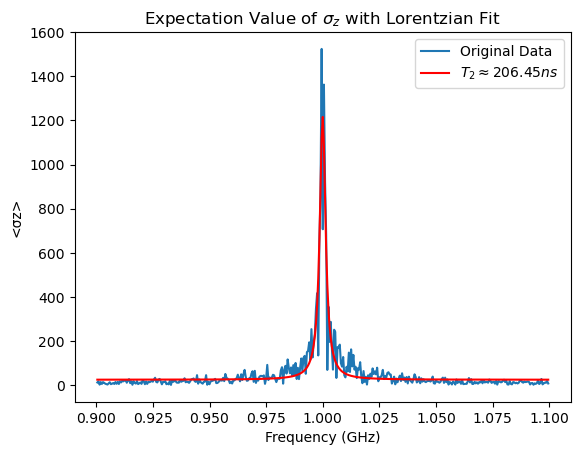

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

## Rabi TLS 1 

### Setup 1

In [129]:

# parameters
samples = 5
g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]


#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1noise=0.128*2*np.pi #driving energy [GHz.rad]
amp1drive=0.1*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

# Noise plus TLS 1 resonant drive
def Ed1(tlist):
    return amp1noise*np.random.normal(0,1,len(tlist))+amp1drive*np.sin((wq1)*tlist)
print(peak)
exps=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1=Ed1)
    exps.append(np.array(res.expect))
    

2.8284271247461903


100%|██████████| 5/5 [14:01<00:00, 168.37s/it]


In [130]:
exp = np.mean(np.array(exps), axis=0)

DC: (50962.7638050605+0j)


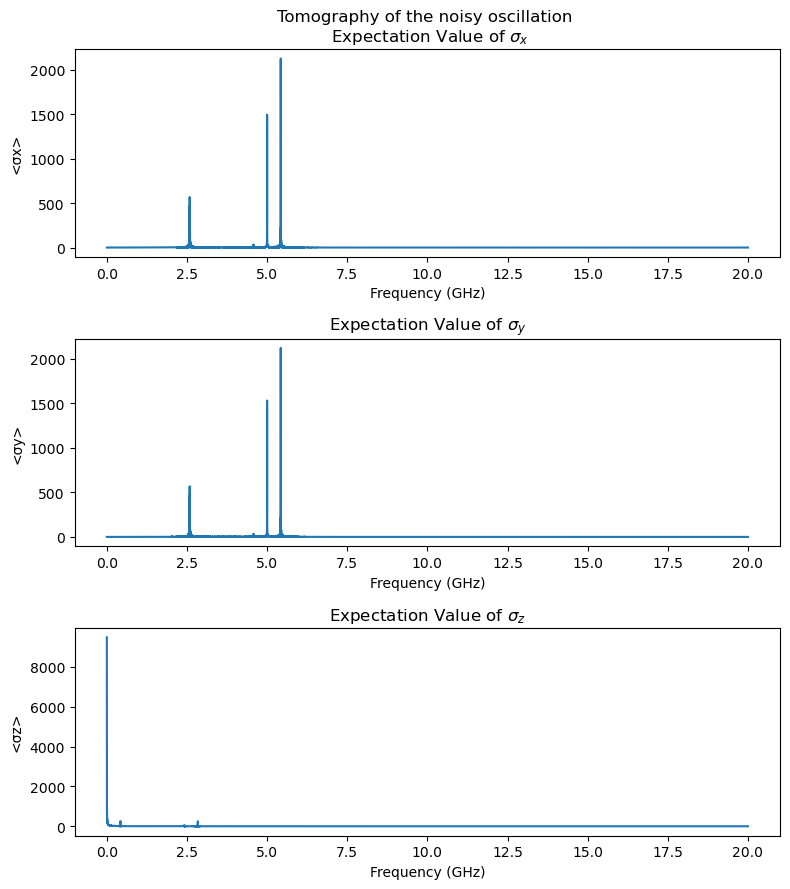

In [131]:
plot_fft_tomography(t, exp)

Fitted Offset: 5.19
Fitted Amplitude (S0): 183.98
Fit
Fitted f0 2.84 GHz


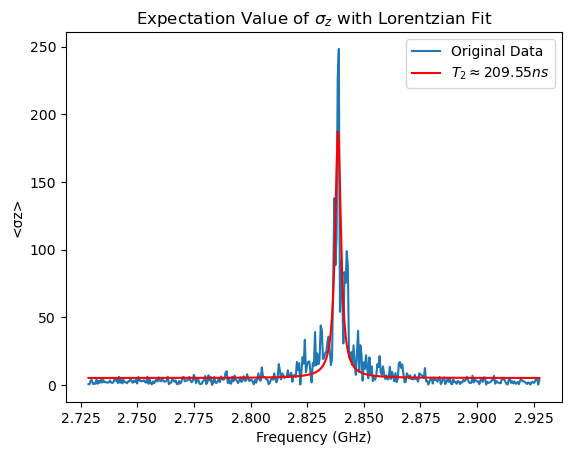

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

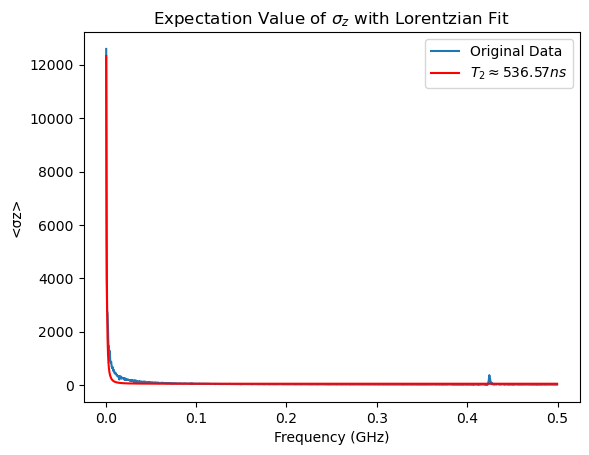

Fitted Offset: 46.03
Fitted Amplitude (S0): 21006.60
Fit
std of increments (volatility): 7.076170127929282e-05


In [141]:
lorenztian_fit(t, exp[2], T2_1,split=1000)

In [142]:
from datetime import datetime
now=datetime.now().strftime(r'%Y-%m-%d_%H-%M-%S')
print(now)
for i, exp in enumerate(exps):
   np.savez(f"qubit_tls_data/rabi_tls_1_setup_1_{now}_{i}.npz", data=np.array(exps))

2025-08-22_06-55-57


### Setup 2

In [143]:

# parameters
samples = 5
g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0noise=0.128*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]

amp1drive=0.1*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)

def Ed0(tlist):
    return amp0noise*np.random.normal(0,1,len(tlist))
# TLS 1 resonant drive
def Ed1(tlist):
    return amp1drive*np.sin((wq1)*tlist)

exps=[]
for i in tqdm(range(samples)):
    t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1=Ed1, Ed0=Ed0)
    exps.append(np.array(res.expect))
    

2.8284271247461903


100%|██████████| 5/5 [19:46<00:00, 237.30s/it]


In [144]:
exp = np.mean(np.array(exps), axis=0)

DC: (43914.237078241014+0j)


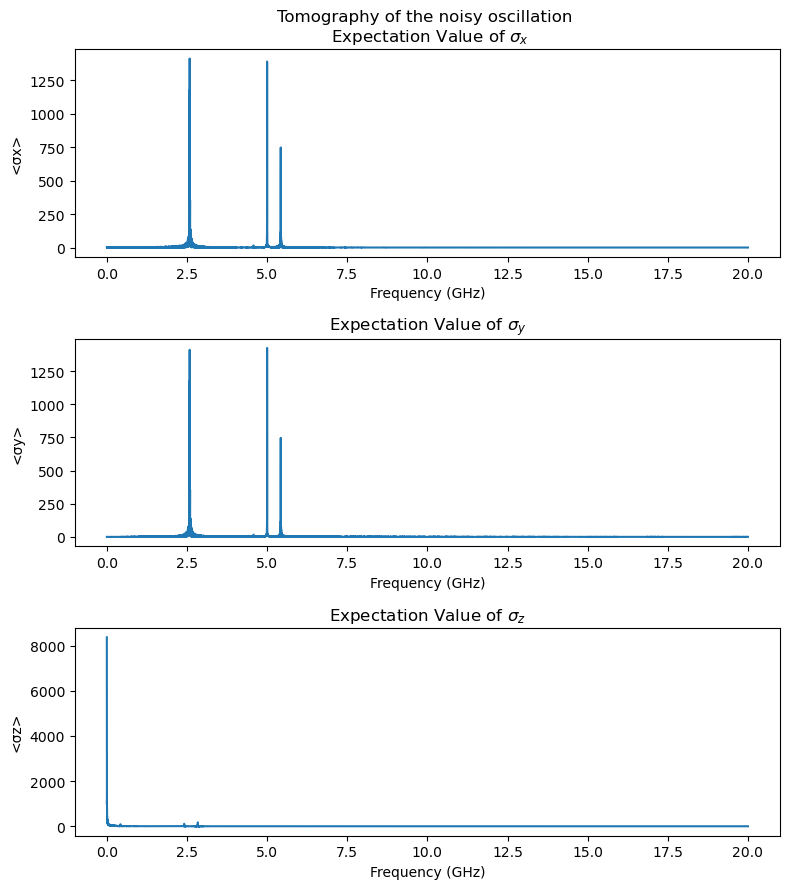

In [145]:
plot_fft_tomography(t, exp)

Fitted Offset: 3.56
Fitted Amplitude (S0): 93.84
Fit
Fitted f0 2.84 GHz


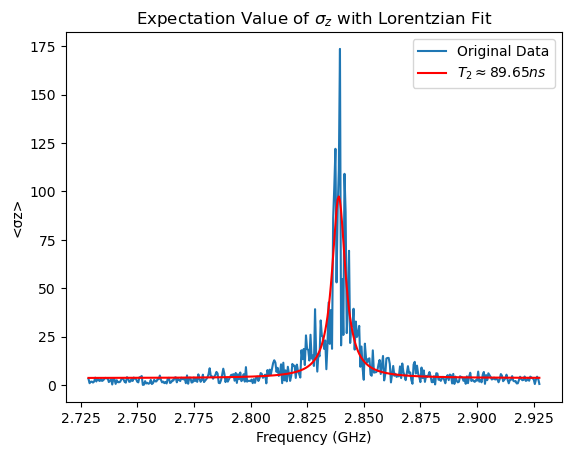

In [ ]:
peak_zoom(t, exp[2], T2_1, peak=peak,zoom=0.1)

In [147]:
from datetime import datetime
now=datetime.now().strftime(r'%Y-%m-%d_%H-%M-%S')
print(now)
for i, exp in enumerate(exps):
   np.savez(f"qubit_tls_data/rabi_tls_1_setup_2_{now}_{i}.npz", data=np.array(exps))

2025-08-22_07-18-20


## Psi0

### Excited state

In [177]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]
def Ed1(tlist):
    return amp1*np.random.normal(0,1,len(tlist))
psi0=qtp.tensor(qtp.basis(2,0), qtp.basis(2,1))
peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1=Ed1,psi0=psi0)

2.8284271247461903


DC: (9680.995123600456+0j)


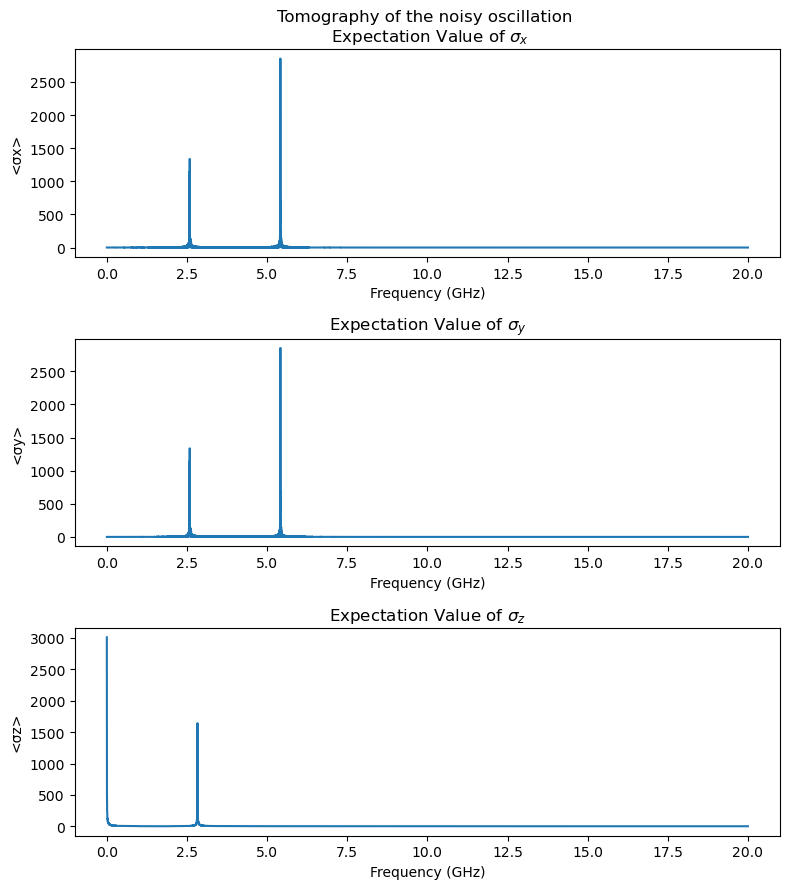

In [178]:
plot_fft_tomography(t, res.expect)

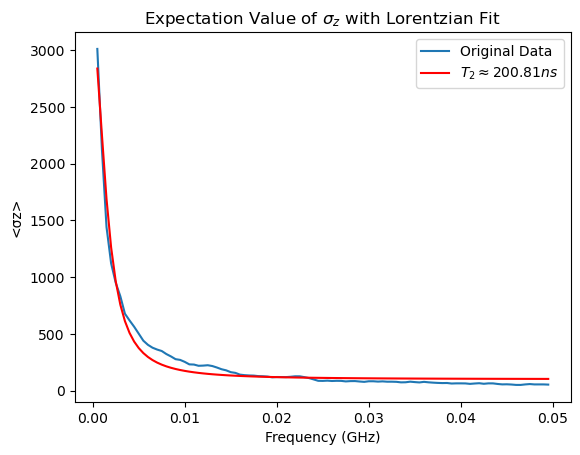

Fitted Offset: 99.83
Fitted Amplitude (S0): 3009.90
Fit
std of increments (volatility): 0.0010091437340784843


In [179]:
lorenztian_fit(t, res.expect[2], T2_0)

Fitted Offset: 11.69
Fitted Amplitude (S0): 1476.83
Fit
Fitted f0 2.83 GHz


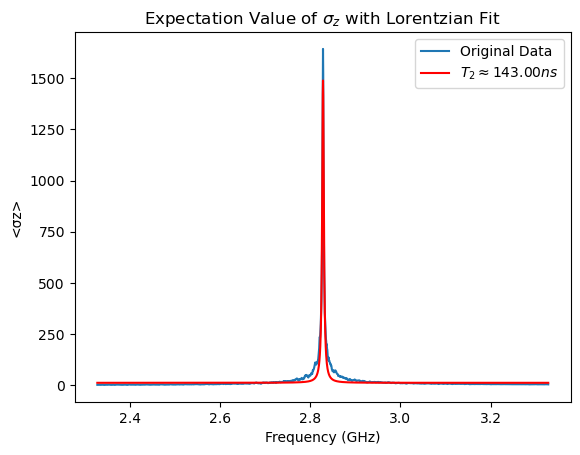

In [ ]:
peak_zoom(t, res.expect[2], T2_1, peak)

### Superposition

In [181]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]
def Ed1(tlist):
   return  amp1*np.random.normal(0,1,len(tlist))
psi0=qtp.tensor(qtp.basis(2,0), (qtp.basis(2, 0) + qtp.basis(2,1)).unit())
peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1=Ed1,psi0=psi0)

2.8284271247461903


DC: (36426.533751504074+0j)


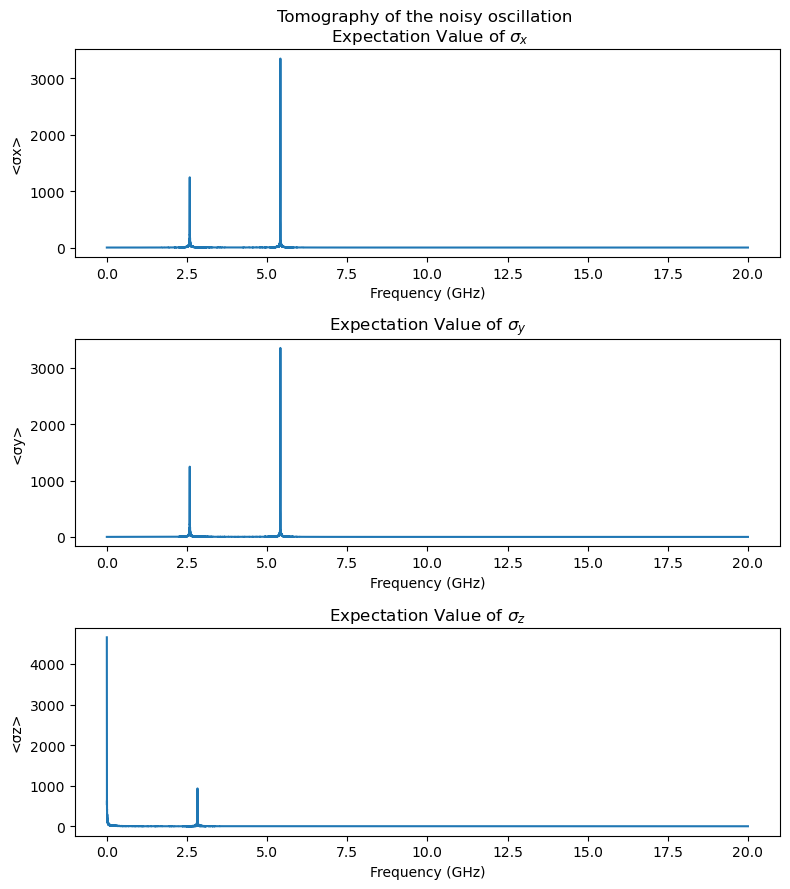

In [182]:
plot_fft_tomography(t, res.expect)

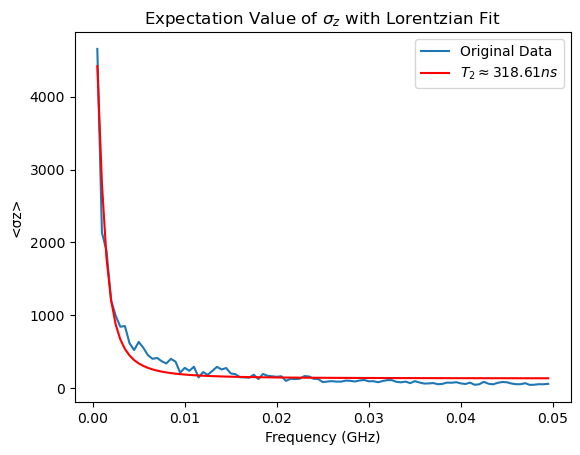

Fitted Offset: 133.83
Fitted Amplitude (S0): 5359.09
Fit
std of increments (volatility): 0.00028734438964054176


In [183]:
lorenztian_fit(t, res.expect[2], T2_0)

Fitted Offset: 5.99
Fitted Amplitude (S0): 766.21
Fit
Fitted f0 2.83 GHz


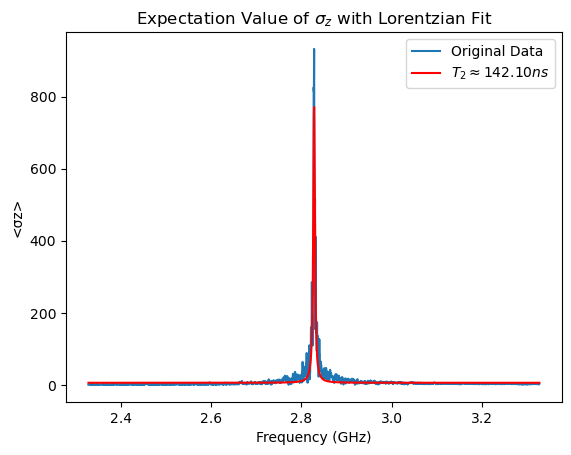

In [ ]:
peak_zoom(t, res.expect[2], T2_1, peak)

### Excited state with noise in qubit 0

In [185]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.128*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]


def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))
psi0=qtp.tensor(qtp.basis(2,0), qtp.basis(2,1))
peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0,psi0=psi0)

2.8284271247461903


DC: (13891.152445912554+0j)


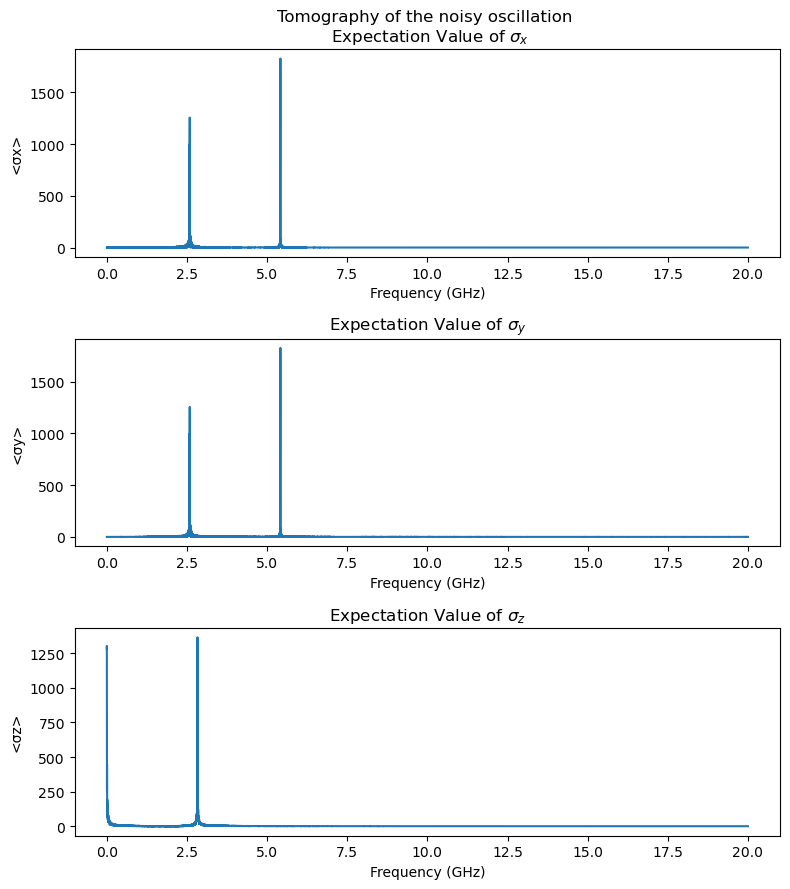

In [186]:
plot_fft_tomography(t, res.expect)

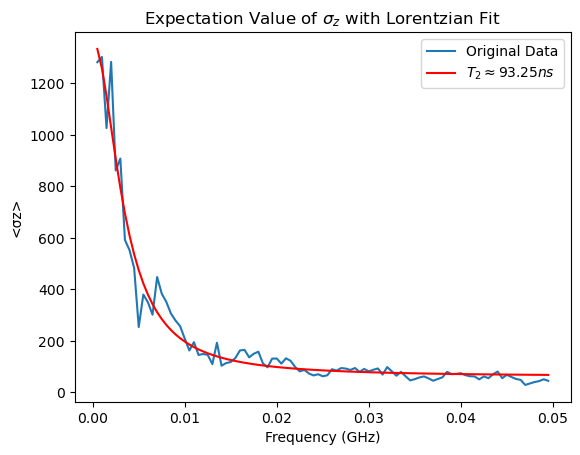

Fitted Offset: 62.05
Fitted Amplitude (S0): 1299.18
Fit
std of increments (volatility): 0.0008807471780679343


In [187]:
lorenztian_fit(t, res.expect[2], T2_0)

Fitted Offset: 10.50
Fitted Amplitude (S0): 1122.82
Fit
Fitted f0 2.83 GHz


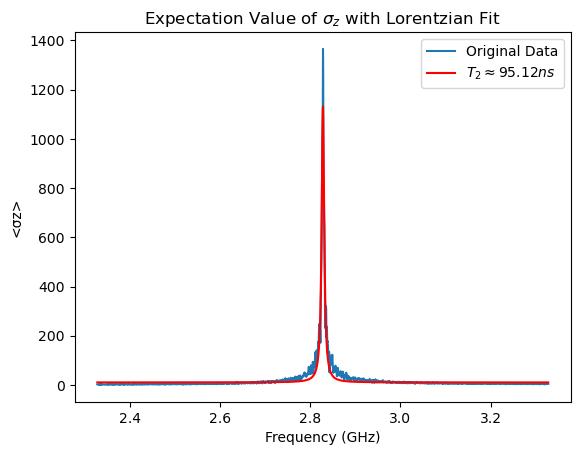

In [ ]:
peak_zoom(t, res.expect[2], T2_1, peak)

# End